In [80]:
import numpy as np
import pandas as pd
import glob
from scipy.io import loadmat
from brainspace.gradient.gradient import GradientMaps
import func_plot as fp
import func_stats as fs
import nibabel as nib
from statsmodels.tools.tools import add_constant
import statsmodels.formula.api as smf
from matplotlib.colors import ListedColormap
"./BD-SCZ/RSFC_HC_SCZ_BD_noGSR/sub*.mat"

'./BD-SCZ/RSFC_HC_SCZ_BD_noGSR/sub*.mat'

## Regress out age and gender + correlation matrix between clinical scores and the mean yeo network gradient (1+3) and eccentricity matrix

Residualization complete.
Residualized data saved. Shape: (187, 43)
Correlation matrix saved. Shape: (28, 14)


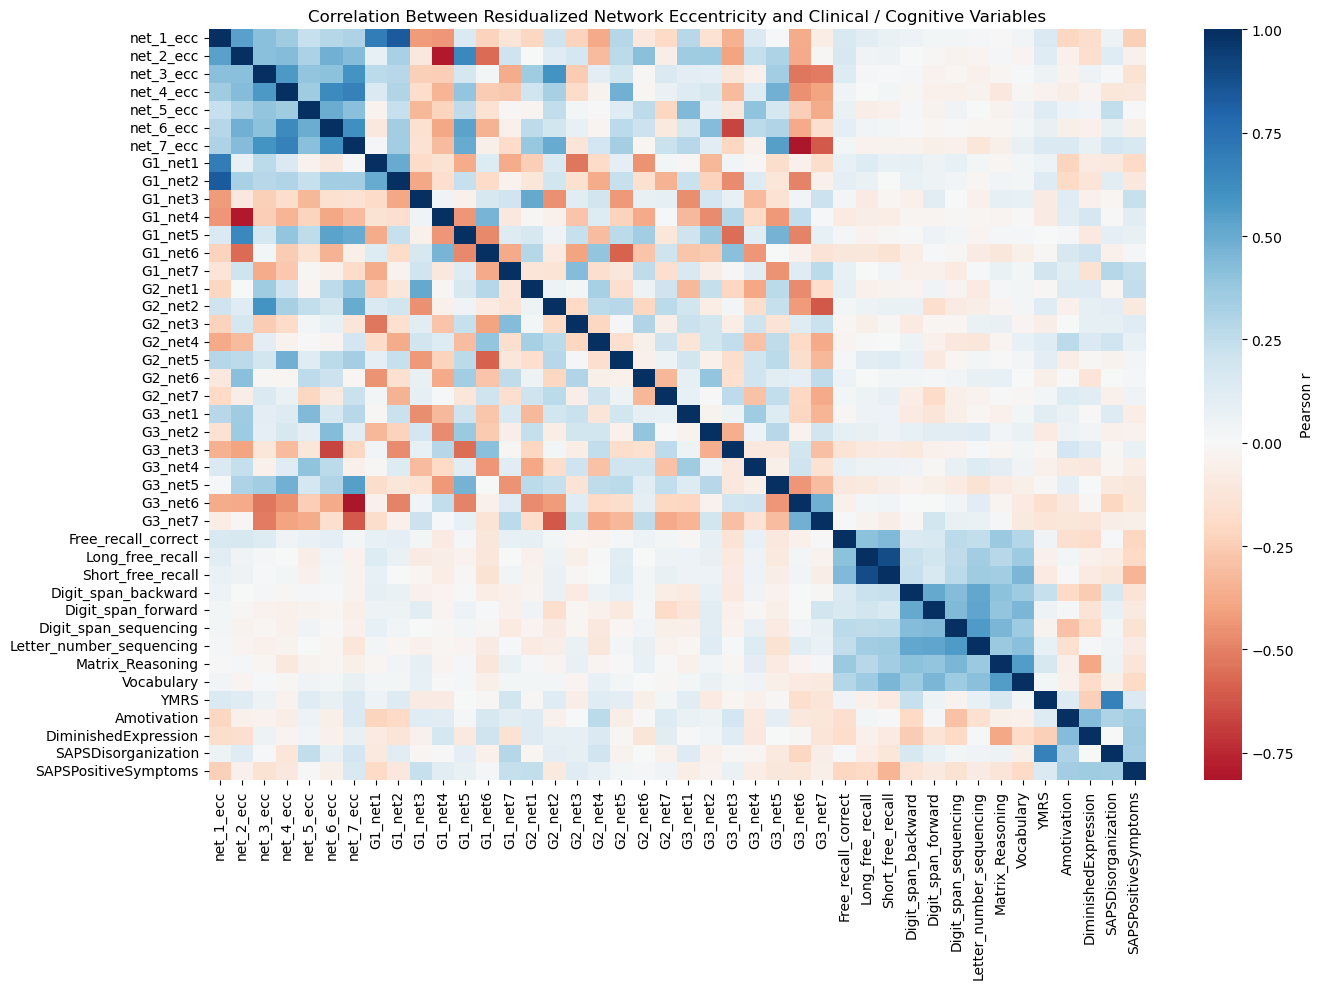

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt

# ------------------------
# 1. Load the merged table
# ------------------------
df = pd.read_excel('Network_level_gradients_ecc_clinical.xlsx')

# Ensure participant ID is string
df['participant_id_num'] = df['participant_id_num'].astype(str)

# ------------------------
# 2. Define columns
# ------------------------
# Brain features: eccentricity + network-level gradients
brain_cols = [c for c in df.columns if 'net_' in c or 'G' in c]

# Clinical/cognitive variables
clinical_cols = [
    'Free_recall_correct', 'Long_free_recall', 'Short_free_recall',
    'Digit_span_backward', 'Digit_span_forward', 'Digit_span_sequencing',
    'Letter_number_sequencing', 'Matrix_Reasoning', 'Vocabulary',
    'YMRS', 'Amotivation', 'DiminishedExpression', 
    'SAPSDisorganization', 'SAPSPositiveSymptoms'
]

# Covariates
covariates = ['age', 'gender']

# ------------------------
# 3. Residualization function
# ------------------------
def residualize(df, target_cols, covariate_cols):
    """
    Regress out covariates from each column in target_cols.
    Returns a dataframe with residuals.
    """
    X = df[covariate_cols]
    X = sm.add_constant(X)
    resid_df = pd.DataFrame(index=df.index)
    
    for col in target_cols:
        if col not in df.columns:
            print(f"Warning: {col} not in dataframe, skipping.")
            continue
        y = df[col]
        model = sm.OLS(y, X, missing='drop').fit()
        resid_df[col] = model.resid
    resid_df['participant_id_num'] = df['participant_id_num']
    return resid_df

# ------------------------
# 4. Residualize brain and clinical variables
# ------------------------
brain_resid = residualize(df, brain_cols, covariates)
clinical_resid = residualize(df, clinical_cols, covariates)

# ------------------------
# 5. Merge residualized tables
# ------------------------
resid_df = pd.merge(brain_resid, clinical_resid, on='participant_id_num', how='inner')

# ------------------------
# 6. Correlation matrix
# ------------------------
# Compute correlations between brain features and clinical variables
corr_matrix = resid_df[brain_cols + clinical_cols].corr()

# Extract only brain vs clinical correlations
brain_vs_clinical = corr_matrix.loc[brain_cols, clinical_cols]

# ------------------------
# 7. Save residualized data and correlation matrix
# ------------------------
resid_df.to_excel('Residualized_Network_Gradients_Eccentricity.xlsx', index=False)
brain_vs_clinical.to_excel('Brain_vs_Clinical_Correlations.xlsx')

print("Residualization complete.")
print("Residualized data saved. Shape:", resid_df.shape)
print("Correlation matrix saved. Shape:", brain_vs_clinical.shape)

# -------------------------------------------
# 5. Plot heatmap
# -------------------------------------------
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix.astype(float), annot=False, fmt=".2f",
            cmap="RdBu_r", center=0, cbar_kws={'label': 'Pearson r'})
plt.title("Correlation Between Residualized Network Eccentricity and Clinical / Cognitive Variables")
plt.tight_layout()
plt.show()


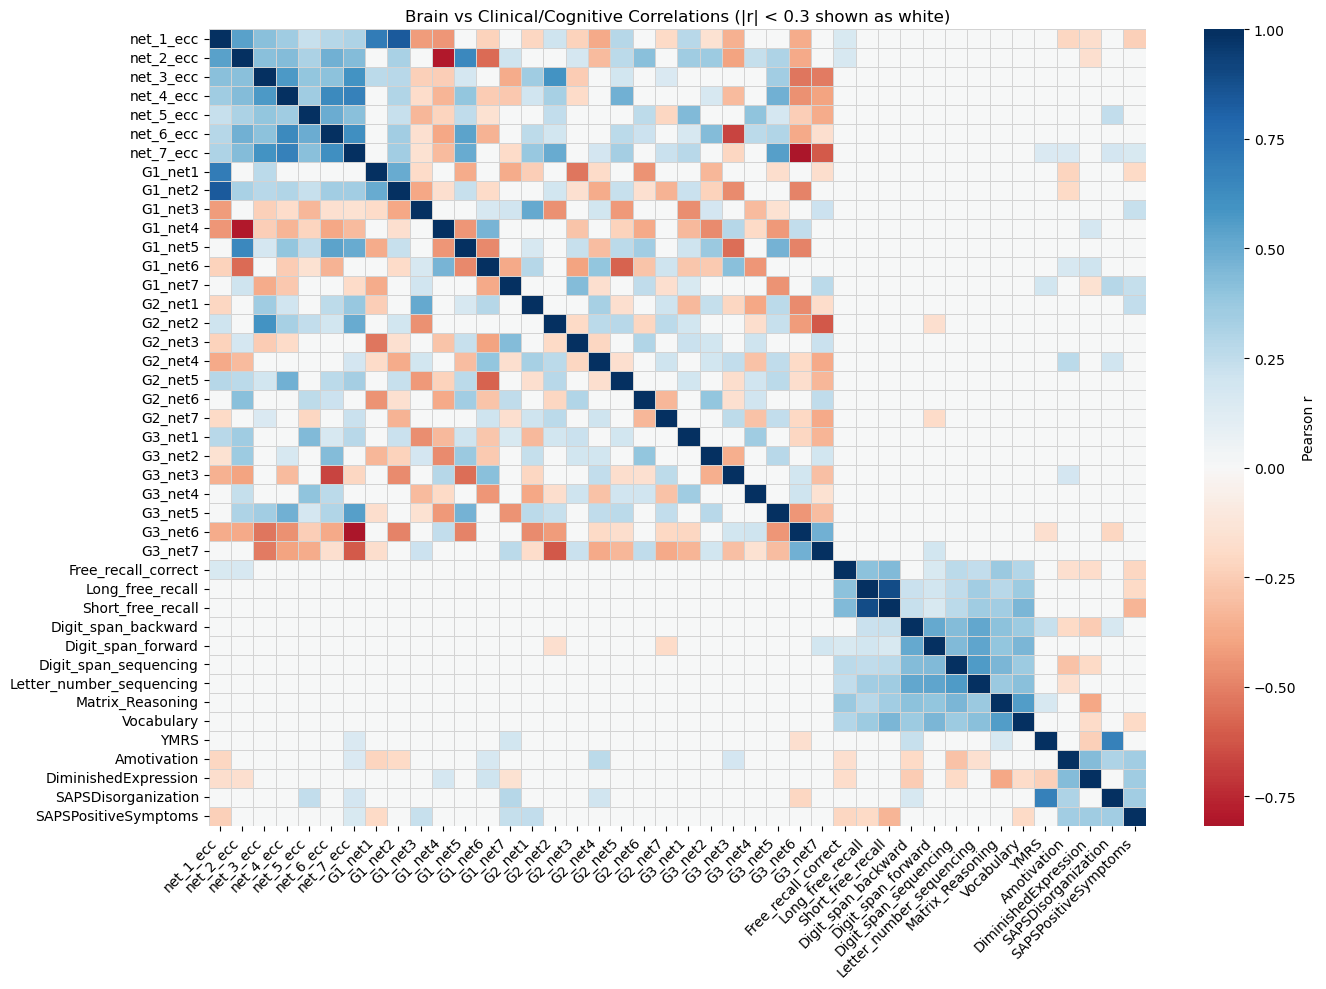

In [ ]:
# Ensure numeric
corr_plot = corr_matrix.copy()

# Mask weak correlations (< 0.3) by setting them to 0
corr_plot_masked = corr_plot.mask(np.abs(corr_plot) < 0.15, 0)

# Plot heatmap with proper diverging colormap (white = 0)
plt.figure(figsize=(14, 10))
sns.heatmap(corr_plot_masked, annot=False, fmt=".2f",
            cmap="RdBu_r", center=0,  # red = positive, blue = negative
            cbar_kws={'label': 'Pearson r'},
            linewidths=0.5, linecolor='lightgrey')

plt.title("Brain vs Clinical/Cognitive Correlations (|r| < 0.3 shown as white)")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Correlation without regression

Full all-vs-all correlation matrix saved. Shape: (45, 45)


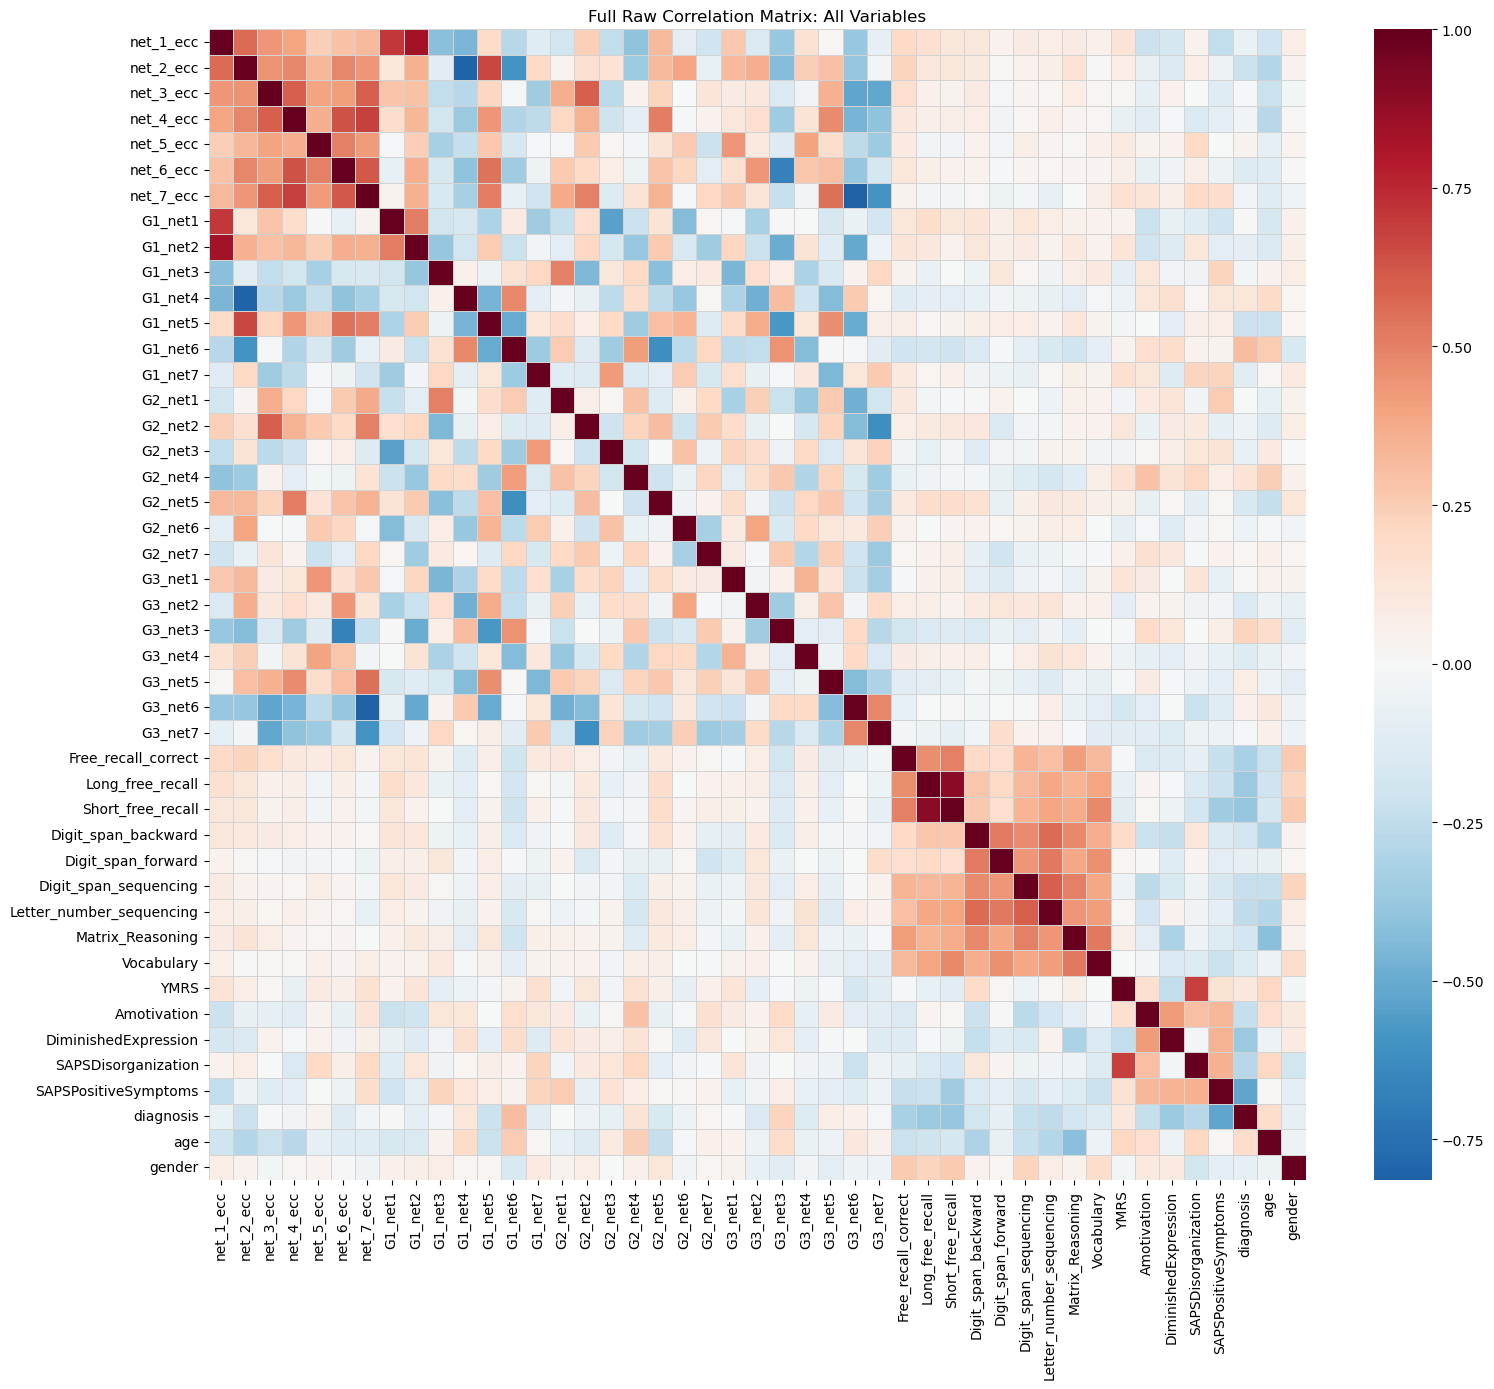

In [106]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ------------------------
# 1. Load data
# ------------------------
df = pd.read_excel('Network_level_gradients_ecc_clinical.xlsx')
df['participant_id_num'] = df['participant_id_num'].astype(str)

# ------------------------
# 2. Convert categorical variables if needed
# ------------------------
if df['gender'].dtype == object:
    df['gender'] = df['gender'].map({'M': 1, 'F': 2})

# ------------------------
# 3. Define all variables to include
# ------------------------
all_vars = [c for c in df.columns if c != 'participant_id_num']

# ------------------------
# 4. Compute full correlation matrix
# ------------------------
corr_matrix = df[all_vars].corr()

# ------------------------
# 5. Save correlation matrix
# ------------------------
corr_matrix.to_excel('All_vs_All_RawCorrelations.xlsx')
print("Full all-vs-all correlation matrix saved. Shape:", corr_matrix.shape)

# ------------------------
# 6. Plot heatmap
# ------------------------
plt.figure(figsize=(16, 14))
sns.heatmap(corr_matrix, cmap="RdBu_r", center=0, annot=False, linewidths=0.5, linecolor='lightgrey')
plt.title("Full Raw Correlation Matrix: All Variables")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


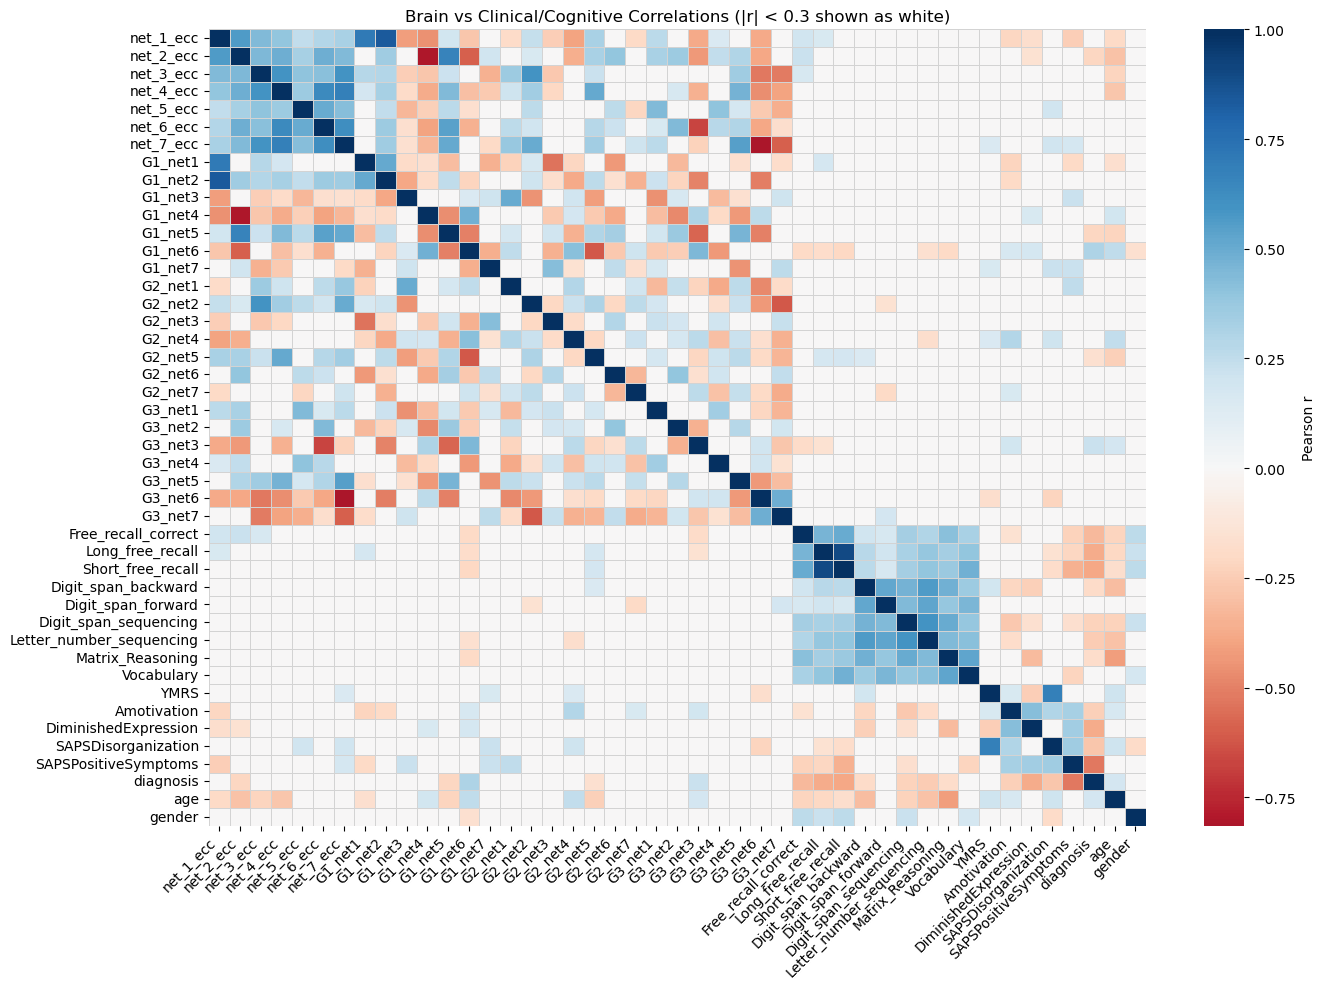

In [ ]:
# Ensure numeric
corr_plot = corr_matrix.copy()

# Mask weak correlations (< 0.3) by setting them to 0
corr_plot_masked = corr_plot.mask(np.abs(corr_plot) < 0.15, 0)

# Plot heatmap with proper diverging colormap (white = 0)
plt.figure(figsize=(14, 10))
sns.heatmap(corr_plot_masked, annot=False, fmt=".2f",
            cmap="RdBu_r", center=0,  # red = positive, blue = negative
            cbar_kws={'label': 'Pearson r'},
            linewidths=0.5, linecolor='lightgrey')

plt.title("Brain vs Clinical/Cognitive Correlations (|r| < 0.3 shown as white)")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# PLS on eccentricity

In [110]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression
from scipy.stats import pearsonr

# ------------------------
# Load network-level eccentricity + clinical/behavior CSV
# ------------------------
net_df = pd.read_excel('./Network_level_gradients_ecc_clinical.xlsx')

# ------------------------
# Define network eccentricity columns (X)
# ------------------------
network_cols = [f'net_{i}_ecc' for i in range(1, 8)]
X = net_df[network_cols].values

# ------------------------
# Define behavioral + clinical columns (Y)
# ------------------------
# Exclude participant_id and network columns; include age and gender
exclude_cols = ['participant_id']
G_cols = [c for c in net_df.columns if c.startswith('G')]
Y_cols = [c for c in net_df.columns if c not in exclude_cols + network_cols + G_cols]
Y = net_df[Y_cols].values

# ------------------------
# Remove rows with NaNs
# ------------------------
nan_mask = np.isnan(X).any(axis=1) | np.isnan(Y).any(axis=1)
X_clean = X[~nan_mask]
Y_clean = Y[~nan_mask]
df_clean = net_df.loc[~nan_mask].copy()

# ------------------------
# Standardize X and Y
# ------------------------
X_std = StandardScaler().fit_transform(X_clean)
Y_std = StandardScaler().fit_transform(Y_clean)

# ------------------------
# Fit PLS (1 LV)
# ------------------------
pls = PLSRegression(n_components=1)
pls.fit(X_std, Y_std)

# Saliences
X_saliences = pls.x_weights_[:, 0]
Y_saliences = pls.y_weights_[:, 0]

# Subject scores
X_scores = pls.x_scores_[:, 0]
Y_scores = pls.y_scores_[:, 0]

# Correlate each behavioral variable with LV behavioral score
behav_corrs = {}
for i, var in enumerate(Y_cols):
    corr, _ = pearsonr(Y_std[:, i], Y_scores)
    behav_corrs[var] = corr

# ------------------------
# Store results in a dictionary
# ------------------------
pls_results = {
    'X_std': X_std,
    'Y_std': Y_std,
    'X_scores': X_scores,
    'Y_scores': Y_scores,
    'X_saliences': X_saliences,
    'Y_saliences': Y_saliences,
    'behav_corrs': behav_corrs,
    'df_clean': df_clean,
    'network_cols': network_cols,
    'Y_cols': Y_cols
}

# ------------------------
# Print summary
# ------------------------
print("PLS: Network eccentricity vs behavior/clinical variables (including age and gender)")
print("X saliences (network-level eccentricity weights):")
for net, w in zip(network_cols, X_saliences):
    print(f"  {net}: {w:.3f}")

print("\nBehavioral correlations with LV:")
for var, corr in behav_corrs.items():
    print(f"  {var:25s}: {corr:.3f}")


PLS: Network eccentricity vs behavior/clinical variables (including age and gender)
X saliences (network-level eccentricity weights):
  net_1_ecc: 0.625
  net_2_ecc: 0.263
  net_3_ecc: 0.289
  net_4_ecc: 0.546
  net_5_ecc: 0.066
  net_6_ecc: 0.136
  net_7_ecc: -0.369

Behavioral correlations with LV:
  participant_id_num       : 0.753
  Free_recall_correct      : 0.614
  Long_free_recall         : 0.523
  Short_free_recall        : 0.554
  Digit_span_backward      : 0.568
  Digit_span_forward       : 0.508
  Digit_span_sequencing    : 0.544
  Letter_number_sequencing : 0.581
  Matrix_Reasoning         : 0.581
  Vocabulary               : 0.536
  YMRS                     : -0.065
  Amotivation              : -0.471
  DiminishedExpression     : -0.424
  SAPSDisorganization      : -0.311
  SAPSPositiveSymptoms     : -0.635
  diagnosis                : 0.754
  age                      : -0.328
  gender                   : 0.236


## Permutation testing

In [111]:
import numpy as np
from sklearn.cross_decomposition import PLSRegression

# -------------------------------
# Permutation testing parameters
# -------------------------------
n_permutations = 15000  # number of permutations
n_components = 1         # LV1 only

results_perm = {}        # store permutation p-values
results = {'network_eccentricity': pls_results}  # single key for simplicity

# -------------------------------
# Run permutation test
# -------------------------------
for name, res in results.items():
    print(f"Permutation testing for {name}...")

    # Retrieve standardized X (network eccentricity) and Y (behavioral/clinical)
    X = res['X_std']  # standardized network-level brain data (n_subjects x 7)
    Y = res['Y_std']  # standardized behavioral/clinical data (n_subjects x n_vars)

    # Fit original PLS to get observed singular value
    pls = PLSRegression(n_components=n_components)
    pls.fit(X, Y)
    
    X_scores = pls.x_scores_[:, 0]
    Y_scores = pls.y_scores_[:, 0]
    obs_singular_value = np.cov(X_scores, Y_scores, bias=True)[0, 1]  # observed covariance

    # -----------------------
    # Run permutations
    # -----------------------
    perm_singular_values = np.zeros(n_permutations)
    for i in range(n_permutations):
        # Shuffle rows of X to break subject correspondence
        X_perm = X[np.random.permutation(X.shape[0]), :]
        pls_perm = PLSRegression(n_components=n_components)
        pls_perm.fit(X_perm, Y)
        X_scores_perm = pls_perm.x_scores_[:, 0]
        Y_scores_perm = pls_perm.y_scores_[:, 0]
        perm_singular_values[i] = np.cov(X_scores_perm, Y_scores_perm, bias=True)[0, 1]

    # Compute p-value: proportion of permuted covariances >= observed
    p_value = np.mean(perm_singular_values >= obs_singular_value)

    # Store results
    results_perm[name] = {
        'obs_singular_value': obs_singular_value,
        'perm_singular_values': perm_singular_values,
        'p_value': p_value
    }

    print(f"{name} LV1 permutation p-value: {p_value:.4f}")


Permutation testing for network_eccentricity...
network_eccentricity LV1 permutation p-value: 0.9548


## Bootstrapping

Bootstrap resampling for network_eccentricity...


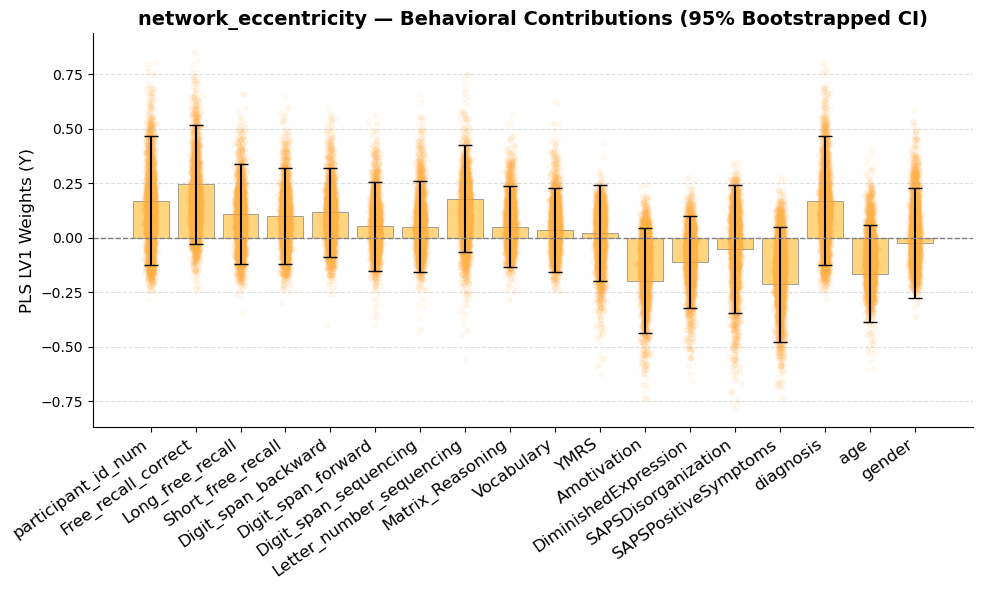

In [112]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample

# -------------------------------
# Bootstrap parameters
# -------------------------------
n_bootstrap = 5000  # number of bootstrap resamples
n_components = 1    # LV1 only
results_boot = {}   # store bootstrap ratios

# Color palette for plotting
bar_color = '#FFD580'
point_color = '#FFB347'
star_color = 'black'

# -------------------------------
# Single “network-level eccentricity” key
# -------------------------------
name = 'network_eccentricity'
res = pls_results  # your network-level PLS results

print(f"Bootstrap resampling for {name}...")

# Standardized X and Y
X = res['X_std']  # n_subjects x 7 networks
Y = res['Y_std']  # n_subjects x n_behav
n_subjects, n_networks = X.shape
n_behav = Y.shape[1]

# Original PLS to get LV1 weights
pls_orig = PLSRegression(n_components=n_components)
pls_orig.fit(X, Y)
X_orig_weights = pls_orig.x_weights_[:, 0]
Y_orig_weights = pls_orig.y_weights_[:, 0]

# -----------------------
# Bootstrap resampling
# -----------------------
X_boot_weights = np.zeros((n_bootstrap, n_networks))
Y_boot_weights = np.zeros((n_bootstrap, n_behav))

for i in range(n_bootstrap):
    # Resample subjects with replacement
    Xb, Yb = resample(X, Y, n_samples=n_subjects, replace=True)

    pls_boot = PLSRegression(n_components=n_components)
    pls_boot.fit(Xb, Yb)
    Xb_weights = pls_boot.x_weights_[:, 0]
    Yb_weights = pls_boot.y_weights_[:, 0]

    # Sign-flipping to align bootstrap LV1 with original LV1
    if np.dot(Xb_weights, X_orig_weights) < 0:
        Xb_weights *= -1
        Yb_weights *= -1

    X_boot_weights[i, :] = Xb_weights
    Y_boot_weights[i, :] = Yb_weights

# -----------------------
# Compute bootstrap ratios
# -----------------------
X_bsr = X_orig_weights / X_boot_weights.std(axis=0)
Y_bsr = Y_orig_weights / Y_boot_weights.std(axis=0)

results_boot[name] = {
    'X_bsr': X_bsr,
    'Y_bsr': Y_bsr,
    'X_boot_weights': X_boot_weights,
    'Y_boot_weights': Y_boot_weights
}

# -----------------------
# Behavioral bar plot visualization
# -----------------------
# Use original Y column names
Y_cols = list(res['behav_corrs'].keys())

# Mean and 95% CI
y_mean = Y_orig_weights
y_sd = Y_boot_weights.std(axis=0)
lower_ci = y_mean - 1.96 * y_sd
upper_ci = y_mean + 1.96 * y_sd

# Determine significance
significant = (lower_ci > 0) | (upper_ci < 0)

fig, ax = plt.subplots(figsize=(10,6))

# Bars with error bars
bars = ax.bar(np.arange(n_behav), y_mean,
              width=0.8,
              yerr=[y_mean - lower_ci, upper_ci - y_mean],
              capsize=5, color=bar_color, edgecolor='gray', linewidth=0.5)

# Overlay bootstrap points
for j in range(n_behav):
    x = np.random.normal(j, 0.05, size=n_bootstrap)
    ax.scatter(x, Y_boot_weights[:, j], color=point_color, alpha=0.05, s=12)

# Zero line
ax.axhline(0, color='gray', linestyle='--', linewidth=1)

# Significance stars
for j, sig in enumerate(significant):
    if sig:
        ax.text(j, upper_ci[j] + 0.02, "*", ha='center', va='bottom',
                fontsize=14, color=star_color, fontweight='bold')

# Labels
ax.set_xticks(np.arange(n_behav))
ax.set_xticklabels(Y_cols, rotation=35, ha='right', fontsize=12)
ax.set_ylabel('PLS LV1 Weights (Y)', fontsize=12)
ax.set_title(f'{name} — Behavioral Contributions (95% Bootstrapped CI)', fontsize=14, fontweight='bold')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.xaxis.grid(False)

plt.tight_layout()
plt.show()


# PLS on network-wise gradients

In [114]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression
from scipy.stats import pearsonr

# ------------------------
# Load network-level gradient + clinical/behavior CSV
# ------------------------
net_df = pd.read_excel('./Network_level_gradients_ecc_clinical.xlsx')

# ------------------------
# Define behavioral variables (clinical + age + gender)
# ------------------------
behavior_cols = [
    'Free_recall_correct', 'Long_free_recall', 'Short_free_recall',
    'Digit_span_backward', 'Digit_span_forward', 'Digit_span_sequencing',
    'Letter_number_sequencing', 'Matrix_Reasoning', 'Vocabulary',
    'YMRS', 'Amotivation', 'DiminishedExpression',
    'SAPSDisorganization', 'SAPSPositiveSymptoms',
    'age', 'gender'
]

# ------------------------
# Loop over gradients
# ------------------------
gradient_names = ['G1', 'G2', 'G3']
pls_results_all = {}

for grad in gradient_names:
    print(f"\n--- Running PLS for {grad} ---")

    # Brain features: Gx_net1 ... Gx_net7
    brain_cols = [f'{grad}_net{i}' for i in range(1, 8)]
    X = net_df[brain_cols].values

    # Behavioral features: clinical + age + gender
    Y = net_df[behavior_cols].values

    # Remove rows with NaNs in X or Y
    nan_mask = np.isnan(X).any(axis=1) | np.isnan(Y).any(axis=1)
    X_clean = X[~nan_mask]
    Y_clean = Y[~nan_mask]
    df_clean = net_df.loc[~nan_mask].copy()

    # Standardize
    X_std = StandardScaler().fit_transform(X_clean)
    Y_std = StandardScaler().fit_transform(Y_clean)

    # Fit PLS (1 LV)
    pls = PLSRegression(n_components=1)
    pls.fit(X_std, Y_std)

    # Saliences and scores
    X_saliences = pls.x_weights_[:, 0]
    Y_saliences = pls.y_weights_[:, 0]
    X_scores = pls.x_scores_[:, 0]
    Y_scores = pls.y_scores_[:, 0]

    # Correlate behavioral variables with LV1
    behav_corrs = {}
    for i, var in enumerate(behavior_cols):
        corr, _ = pearsonr(Y_std[:, i], Y_scores)
        behav_corrs[var] = corr

    # Store results
    pls_results_all[grad] = {
        'X_std': X_std,
        'Y_std': Y_std,
        'X_scores': X_scores,
        'Y_scores': Y_scores,
        'X_saliences': X_saliences,
        'Y_saliences': Y_saliences,
        'behav_corrs': behav_corrs,
        'df_clean': df_clean,
        'brain_cols': brain_cols,
        'behavior_cols': behavior_cols
    }

    # Print summary
    print(f"{grad} — Brain saliences:")
    for b, w in zip(brain_cols, X_saliences):
        print(f"  {b}: {w:.3f}")
    print(f"{grad} — Correlations with LV1 scores:")
    for var, corr in behav_corrs.items():
        print(f"  {var}: {corr:.3f}")



--- Running PLS for G1 ---
G1 — Brain saliences:
  G1_net1: 0.692
  G1_net2: 0.414
  G1_net3: -0.127
  G1_net4: -0.377
  G1_net5: -0.016
  G1_net6: -0.428
  G1_net7: -0.094
G1 — Correlations with LV1 scores:
  Free_recall_correct: 0.663
  Long_free_recall: 0.593
  Short_free_recall: 0.640
  Digit_span_backward: 0.514
  Digit_span_forward: 0.391
  Digit_span_sequencing: 0.591
  Letter_number_sequencing: 0.500
  Matrix_Reasoning: 0.576
  Vocabulary: 0.514
  YMRS: -0.068
  Amotivation: -0.516
  DiminishedExpression: -0.456
  SAPSDisorganization: -0.291
  SAPSPositiveSymptoms: -0.613
  age: -0.271
  gender: 0.338

--- Running PLS for G2 ---
G2 — Brain saliences:
  G2_net1: 0.165
  G2_net2: 0.133
  G2_net3: 0.387
  G2_net4: 0.683
  G2_net5: -0.376
  G2_net6: -0.178
  G2_net7: 0.408
G2 — Correlations with LV1 scores:
  Free_recall_correct: -0.574
  Long_free_recall: -0.536
  Short_free_recall: -0.560
  Digit_span_backward: -0.542
  Digit_span_forward: -0.476
  Digit_span_sequencing: -0.612


## Permutation testing

In [116]:
import numpy as np
from sklearn.cross_decomposition import PLSRegression

# ---------------------------------------
# Permutation parameters
# ---------------------------------------
n_permutations = 15000
n_components = 1

perm_results = {}

# ---------------------------------------
# Loop over all gradients
# ---------------------------------------
for grad, res in pls_results_all.items():

    print(f"\nRunning permutation test for {grad} ...")

    X = res['X_std']          # standardized brain features (net1..net7)
    Y = res['Y_std']          # standardized behavior features

    # Fit original PLS
    pls = PLSRegression(n_components=n_components)
    pls.fit(X, Y)

    X_scores = pls.x_scores_[:, 0]
    Y_scores = pls.y_scores_[:, 0]

    # observed covariance = singular value
    obs_singular_val = np.cov(X_scores, Y_scores, bias=True)[0, 1]

    # store permutation values
    perm_vals = np.zeros(n_permutations)

    for i in range(n_permutations):

        # shuffle subjects
        X_perm = X[np.random.permutation(X.shape[0]), :]

        pls_p = PLSRegression(n_components=1)
        pls_p.fit(X_perm, Y)

        Xs = pls_p.x_scores_[:, 0]
        Ys = pls_p.y_scores_[:, 0]

        perm_vals[i] = np.cov(Xs, Ys, bias=True)[0, 1]

    # p-value
    p_val = np.mean(perm_vals >= obs_singular_val)

    perm_results[grad] = {
        "obs_singular_value": obs_singular_val,
        "perm_singular_values": perm_vals,
        "p_value": p_val
    }

    print(f"{grad} — LV1 permutation p = {p_val:.5f}")



Running permutation test for G1 ...
G1 — LV1 permutation p = 0.77107

Running permutation test for G2 ...
G2 — LV1 permutation p = 0.70373

Running permutation test for G3 ...
G3 — LV1 permutation p = 0.35413


## Bootstrap


Bootstrapping LV1 for G1 ...


c:\Users\ferraras\AppData\Local\miniforge3\envs\gradient\lib\site-packages\sklearn\cross_decomposition\_pls.py:104: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)


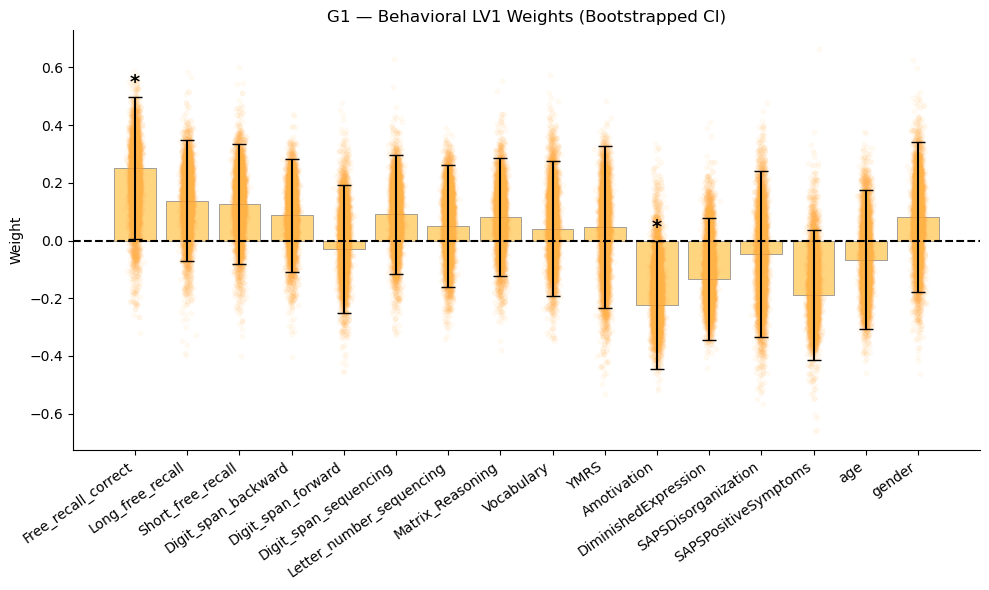


Bootstrapping LV1 for G2 ...


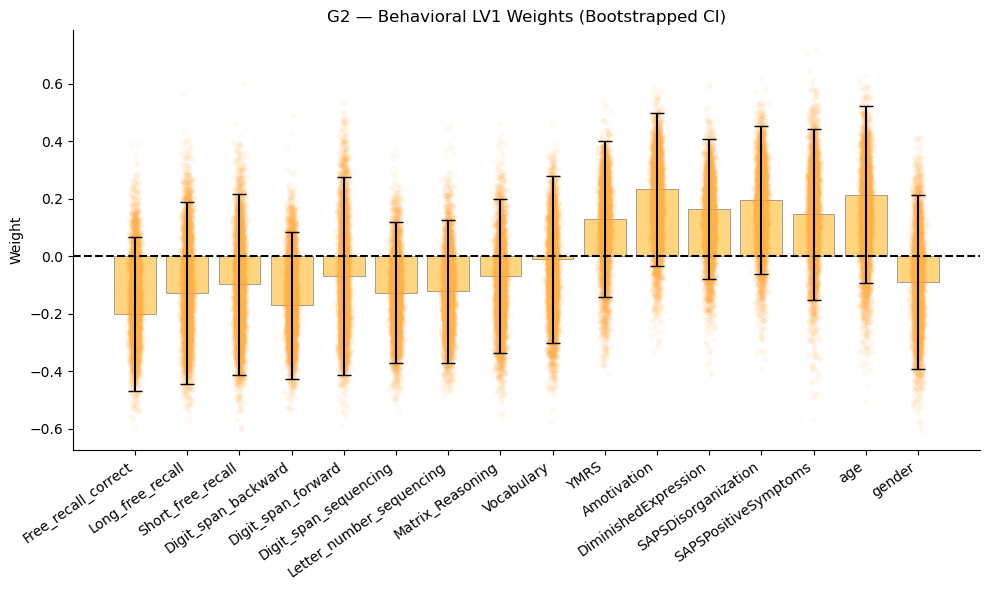


Bootstrapping LV1 for G3 ...


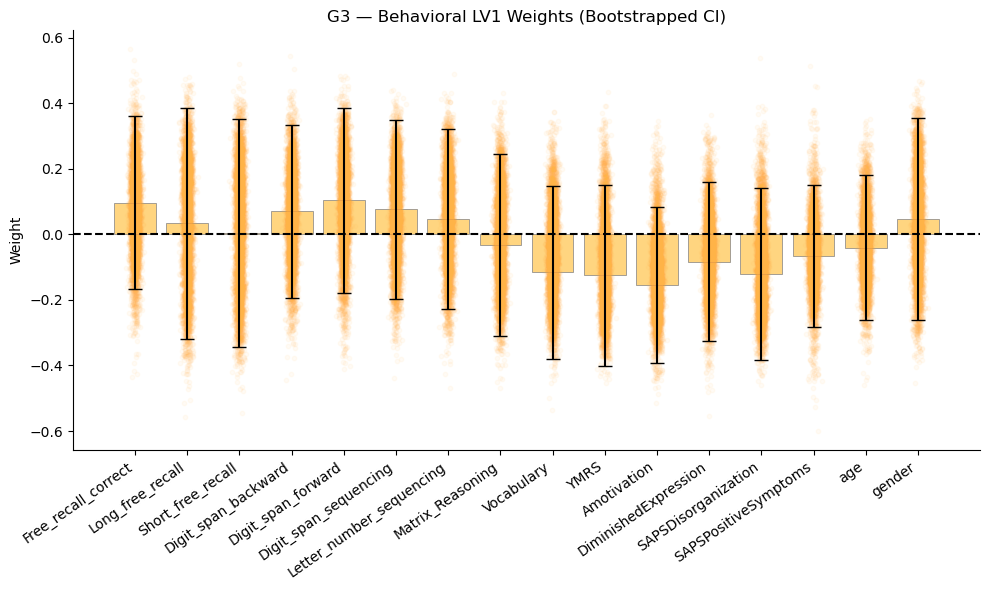

In [117]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression
from sklearn.utils import resample

# ---------------------------------------
# Bootstrap parameters
# ---------------------------------------
n_bootstrap = 5000
n_components = 1

bootstrap_results = {}

for grad, res in pls_results_all.items():

    print(f"\nBootstrapping LV1 for {grad} ...")

    X = res['X_std']
    Y = res['Y_std']

    brain_cols = res['brain_cols']
    behavior_cols = res['behavior_cols']

    n_sub, n_brain = X.shape
    n_beh = Y.shape[1]

    # ---------------------------------------
    # Original PLS
    # ---------------------------------------
    pls = PLSRegression(n_components=1)
    pls.fit(X, Y)

    Xw_orig = pls.x_weights_[:, 0]
    Yw_orig = pls.y_weights_[:, 0]

    # ---------------------------------------
    # Bootstrap arrays
    # ---------------------------------------
    Xw_boot = np.zeros((n_bootstrap, n_brain))
    Yw_boot = np.zeros((n_bootstrap, n_beh))

    for b in range(n_bootstrap):

        Xb, Yb = resample(X, Y, n_samples=n_sub, replace=True)

        pls_b = PLSRegression(n_components=1)
        pls_b.fit(Xb, Yb)

        Xw_b = pls_b.x_weights_[:, 0]
        Yw_b = pls_b.y_weights_[:, 0]

        # align sign
        if np.dot(Xw_b, Xw_orig) < 0:
            Xw_b *= -1
            Yw_b *= -1

        Xw_boot[b, :] = Xw_b
        Yw_boot[b, :] = Yw_b

    # ---------------------------------------
    # Compute bootstrap ratios (BSR)
    # ---------------------------------------
    X_bsr = Xw_orig / Xw_boot.std(axis=0)
    Y_bsr = Yw_orig / Yw_boot.std(axis=0)

    # Confidence intervals for Y behavior variables
    Y_sd = Yw_boot.std(axis=0)
    lower_ci = Yw_orig - 1.96 * Y_sd
    upper_ci = Yw_orig + 1.96 * Y_sd

    significant = (lower_ci > 0) | (upper_ci < 0)

    # ---------------------------------------
    # Store results
    # ---------------------------------------
    bootstrap_results[grad] = {
        "X_boot_weights": Xw_boot,
        "Y_boot_weights": Yw_boot,
        "X_bsr": X_bsr,
        "Y_bsr": Y_bsr,
        "lower_ci": lower_ci,
        "upper_ci": upper_ci,
        "significant": significant
    }

    # ---------------------------------------
    # Plot behavioral Y weights
    # ---------------------------------------
    fig, ax = plt.subplots(figsize=(10, 6))

    idx = np.arange(n_beh)

    ax.bar(idx, Yw_orig, yerr=[Yw_orig - lower_ci, upper_ci - Yw_orig],
           capsize=5, color="#FFD580", edgecolor="gray", linewidth=0.5)

    for j in range(n_beh):
        jitter = np.random.normal(j, 0.05, size=n_bootstrap)
        ax.scatter(jitter, Yw_boot[:, j], alpha=0.05, color="#FFB347", s=10)

    ax.axhline(0, color='black', linestyle='--')

    # stars
    for j, sig in enumerate(significant):
        if sig:
            ax.text(j, upper_ci[j] + 0.03, "*",
                    ha='center', fontsize=14, fontweight='bold')

    ax.set_xticks(idx)
    ax.set_xticklabels(behavior_cols, rotation=35, ha='right')
    ax.set_title(f"{grad} — Behavioral LV1 Weights (Bootstrapped CI)")
    ax.set_ylabel("Weight")

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()


# Regression model

In [130]:
import pandas as pd
import statsmodels.api as sm

# ------------------------
# Load data
# ------------------------
df = pd.read_excel('Network_level_gradients_ecc_clinical.xlsx')

# ------------------------
# Define predictors
# ------------------------
symptom_cols = ['YMRS', 'Amotivation', 'DiminishedExpression', 
                'SAPSDisorganization', 'SAPSPositiveSymptoms']  # include if exists
covariates = ['age', 'gender']
predictors = symptom_cols + covariates

# ------------------------
# Define brain features
# ------------------------
gradients = ['G1', 'G2', 'G3']
networks = [f'net{i}' for i in range(1, 8)]  # 7 networks

# ------------------------
# Store results
# ------------------------
regression_results = {}

# ------------------------
# Loop over gradients and networks
# ------------------------
for grad in gradients:
    grad_cols = [f'{grad}_{net}' for net in networks]
    regression_results[grad] = {}

    for net_col in grad_cols:
        # Drop rows with NaNs
        df_clean = df[predictors + [net_col]].dropna()
        X = df_clean[predictors]
        y = df_clean[net_col]

        # Add constant for intercept
        X = sm.add_constant(X)

        # Fit OLS model
        model = sm.OLS(y, X).fit()

        # Store results
        regression_results[grad][net_col] = {
            'params': model.params,
            'pvalues': model.pvalues,
            'rsquared': model.rsquared,
            'adj_rsquared': model.rsquared_adj
        }


In [136]:
from statsmodels.stats.multitest import multipletests

# ------------------------
# Convert results to DataFrame
# ------------------------
rows = []

for grad, nets in regression_results.items():
    for net_col, stats in nets.items():
        for predictor in stats['params'].index:
            row = {
                'Gradient': grad,
                'Network': net_col,
                'Predictor': predictor,
                'Beta': stats['params'][predictor],
                'p_raw': stats['pvalues'][predictor],
                'R2': stats['rsquared'],
                'Adj_R2': stats['adj_rsquared']
            }
            rows.append(row)

regression_summary = pd.DataFrame(rows)

# ------------------------
# Correct p-values for multiple comparisons (FDR)
# ------------------------
# Apply FDR across all rows
reject, p_corrected, _, _ = multipletests(regression_summary['p_raw'], method='fdr_bh')
regression_summary['p_fdr'] = p_corrected
regression_summary['significant_fdr'] = reject

regression_summary.sort_values('p_fdr', inplace=True)
regression_summary.to_excel('NetworkWise_Regression_Summary_FDR.xlsx', index=False)
print("Regression summary with FDR correction saved. Shape:", regression_summary.shape)
regression_summary


Regression summary with FDR correction saved. Shape: (168, 9)


,Gradient,Network,Predictor,Beta,p_raw,R2,Adj_R2,p_fdr,significant_fdr
152,G3,G3_net6,const,-0.498186,1.427139e-09,0.064151,-0.032187,2.397594e-07,True
32,G1,G1_net5,const,0.363361,2.109720e-08,0.056987,-0.040088,1.181443e-06,True
128,G3,G3_net3,const,-0.437371,1.906244e-08,0.054057,-0.043319,1.181443e-06,True
8,G1,G1_net2,const,0.635958,7.189465e-08,0.088062,-0.005814,3.019575e-06,True
56,G2,G2_net1,const,0.308869,1.958364e-07,0.147126,0.059330,5.483419e-06,True
...,...,...,...,...,...,...,...,...,...
150,G3,G3_net5,age,0.000078,9.472620e-01,0.066931,-0.029121,9.833535e-01,False
155,G3,G3_net6,DiminishedExpression,0.000123,9.606094e-01,0.064151,-0.032187,9.833535e-01,False
138,G3,G3_net4,Amotivation,-0.000058,9.737908e-01,0.049476,-0.048372,9.837609e-01,False
167,G3,G3_net7,gender,-0.000599,9.779052e-01,0.045542,-0.052711,9.837609e-01,False


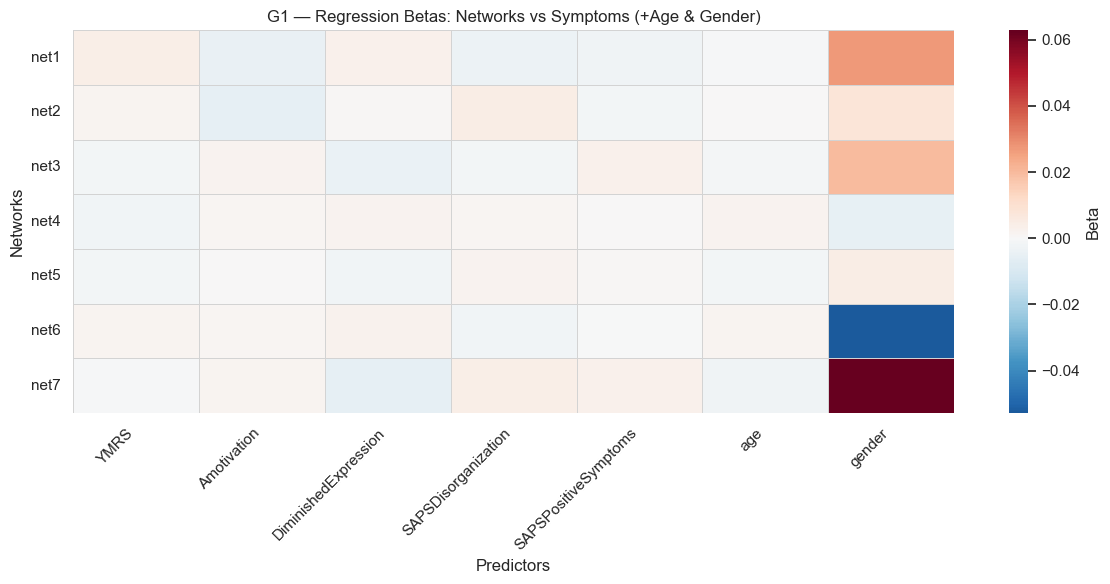

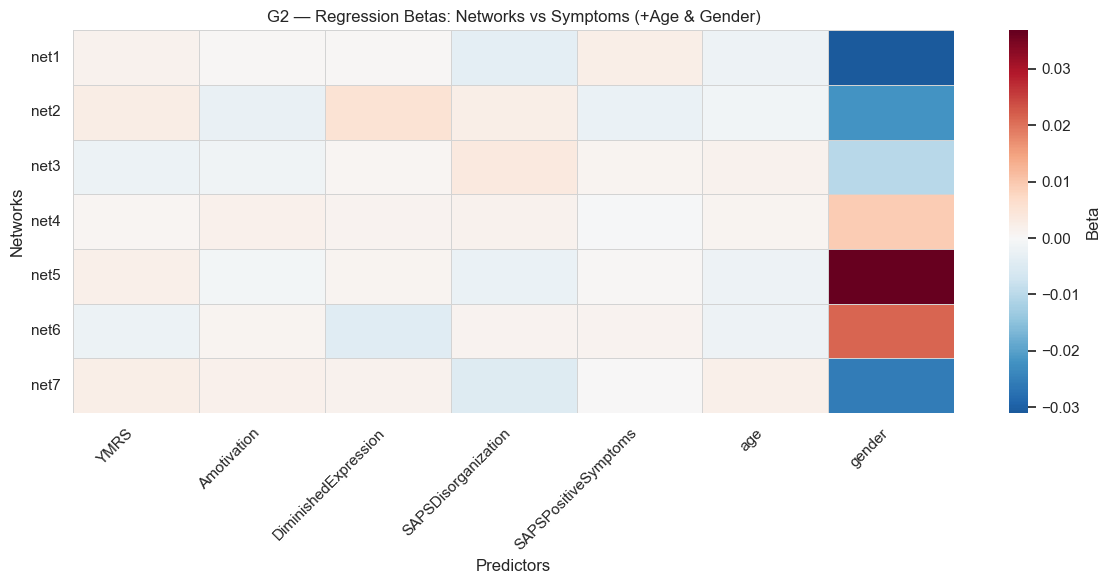

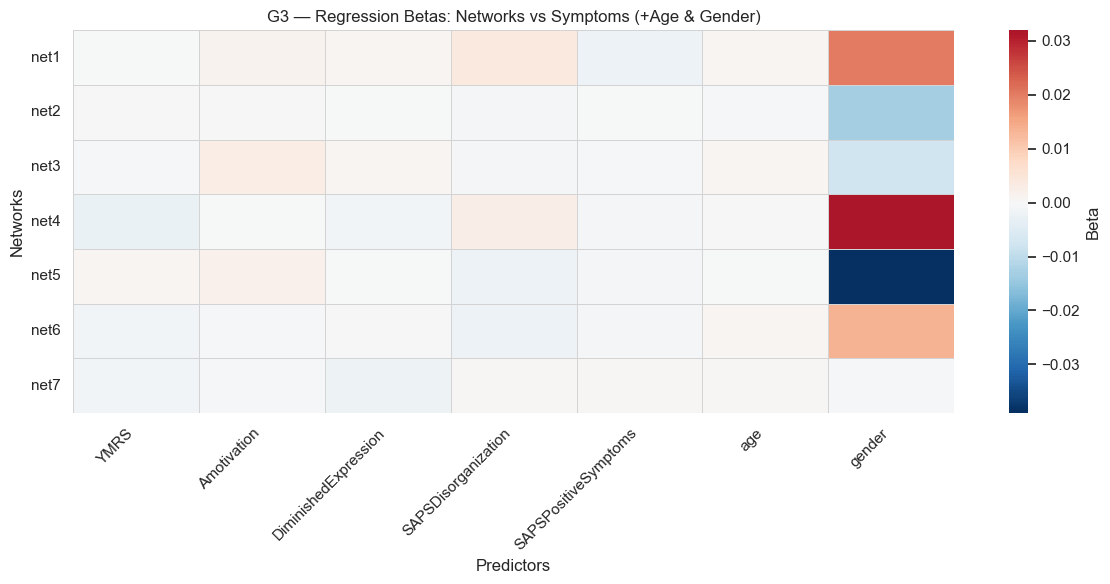

In [134]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------
# Define gradients and networks
# ------------------------
gradients = ['G1', 'G2', 'G3']
networks = [f'net{i}' for i in range(1, 8)]
predictors = ['YMRS', 'Amotivation', 'DiminishedExpression', 
              'SAPSDisorganization', 'SAPSPositiveSymptoms', 'age', 'gender']

# ------------------------
# Loop over gradients
# ------------------------
for grad in gradients:
    beta_matrix = np.zeros((len(networks), len(predictors)))
    star_matrix = np.full((len(networks), len(predictors)), '', dtype=object)
    
    for i, net in enumerate(networks):
        net_col = f'{grad}_{net}'
        for j, predictor in enumerate(predictors):
            subset = regression_summary[
                (regression_summary['Gradient'] == grad) & 
                (regression_summary['Network'] == net_col) & 
                (regression_summary['Predictor'] == predictor)
            ]
            if subset.empty:
                beta = np.nan
                sig = False
            else:
                beta = subset['Beta'].values[0]
                sig = subset['significant_fdr'].values[0]
            
            beta_matrix[i, j] = beta
            if sig:
                star_matrix[i, j] = '*'  # mark FDR-significant effects
    
    # ------------------------
    # Plot heatmap
    # ------------------------
    plt.figure(figsize=(12, 6))
    ax = sns.heatmap(beta_matrix, annot=star_matrix, fmt='',
                     cmap='RdBu_r', center=0,
                     xticklabels=predictors, yticklabels=networks,
                     linewidths=0.5, linecolor='lightgrey', cbar_kws={'label': 'Beta'})
    
    plt.title(f'{grad} — Regression Betas: Networks vs Symptoms (+Age & Gender)')
    plt.xlabel('Predictors')
    plt.ylabel('Networks')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
